# CWRU Bearing Fault Classification

CWRU Bearing dataset: an open-source dataset by Case School of Engineering of the Case Western Reserve University (CWRU) consisting of vibration signals for fault diagnosis in rolling element bearings under various loads and fault severities.

### Dataset 

[Dataset Link](https://github.com/srigas/CWRU_Bearing_NumPy)

This GitHub dataset consists of NumPy .npz version (CWRU_Bearing_NumPy) – Modern and standardized.

Each file contains arrays for available sensors (DE, FE, BA).

Signals are consistent in length (~120k samples).

Organized by RPM, fault type, fault size, and position.

Some Redundancies are also found and removed . 

## 1D- Model

Testing a simple 2-layer 1D CNN architecture.

Focus on Drive End (DE) signals only (common practice for better signal quality).

Use 12 kHz and 48 kHz DE files (filtered by 'DE' in filename).

Segment signals into 1024-point windows (standard length; adjustable if needed).

10 classes: 0=Normal, 1=B7, 2=B14, 3=B21, 4=IR7, 5=IR14, 6=IR21, 7=OR7, 8=OR14, 9=OR21 (combining OR positions, skipping 28 mil faults for consistency across loads).

Train/test split: 80/20, stratified by class.

Training: 20 epochs, Adam optimizer, cross-entropy loss, batch size 64. Includes validation accuracy reporting.

Device: GPU if available, else CPU.

Normalization: Per-segment z-score.

In [1]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

# Class mapping – 10 classes, skipping 28 mil faults
class_map = {
    'Normal': 0,
    'B7': 1, 'B14': 2, 'B21': 3,
    'IR7': 4, 'IR14': 5, 'IR21': 6,
    'OR7': 7, 'OR14': 8, 'OR21': 9
}

def get_label(filename):
    fn = os.path.basename(filename).replace('.npz', '')
    if 'Normal' in fn:
        return 0
    
    parts = fn.split('_')
    if len(parts) < 3:
        return None
    
    fault = parts[1]
    if fault.startswith('OR@'):
        fault = 'OR'
        size_part = parts[2] if len(parts) > 2 else ''
    else:
        size_part = parts[2]
    
    if '28' in size_part:
        return None
    
    key = fault + size_part[:2]  # B7, IR14, OR21, etc.
    return class_map.get(key)

def load_dataset(data_dir, seg_len=1024):
    signals = []
    labels = []
    
    for root, _, files in os.walk(data_dir):
        for file in files:
            if not file.endswith('.npz'):
                continue
            if 'DE' not in file.upper():
                continue
                
            path = os.path.join(root, file)
            label = get_label(path)
            if label is None:
                continue
                
            try:
                data = np.load(path)
                signal = data.get('DE')
                if signal is None:
                    continue
                
                # Force 1D
                signal = np.squeeze(signal)
                if signal.ndim != 1:
                    print(f"Warning: {file} DE signal after squeeze has shape {signal.shape} – skipping")
                    continue
                
                if len(signal) < seg_len:
                    continue
                
                num_segs = len(signal) // seg_len
                for i in range(num_segs):
                    seg = signal[i*seg_len : (i+1)*seg_len]
                    seg = np.squeeze(seg)  # extra safety
                    if seg.ndim != 1 or len(seg) != seg_len:
                        continue
                    signals.append(seg)
                    labels.append(label)
            except Exception as e:
                print(f"Error loading {file}: {e}")
                continue
    
    if not signals:
        return np.array([]), np.array([])
    
    signals = np.array(signals, dtype=np.float32)   # should now be (N, seg_len)
    labels  = np.array(labels, dtype=np.int64)
    
    if signals.ndim != 2 or signals.shape[1] != seg_len:
        raise ValueError(f"Final signals shape invalid: {signals.shape} (expected (N, {seg_len}))")
    
    print(f"Raw signals shape after loading: {signals.shape}")
    return signals, labels

def normalize_signals(signals):
    if signals.ndim != 2:
        raise ValueError(f"normalize expects 2D array, got {signals.shape}")
    means = signals.mean(axis=1, keepdims=True)
    stds  = signals.std(axis=1, keepdims=True) + 1e-8
    signals[:] = (signals - means) / stds
    return signals

class BearingDataset(Dataset):
    def __init__(self, X, y):
        if X.ndim != 2:
            raise ValueError(f"BearingDataset expects X shape (N, L), got {X.shape}")
        self.X = torch.from_numpy(X).float().unsqueeze(1)  # → (N, 1, L)
        self.y = torch.from_numpy(y).long()
        print(f"Dataset created – input shape: {self.X.shape}")

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class CNN1D(nn.Module):
    def __init__(self, input_len=1024, num_classes=10):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=9, stride=1, padding=4),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.AvgPool1d(kernel_size=2, stride=2)
        )
        flattened_size = 128 * (input_len // 4)
        self.fc = nn.Linear(flattened_size, num_classes)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# ────────────────────────────────────────────────
if __name__ == '__main__':
    data_dir = os.path.join('..', 'DataSets', 'CWRU', 'CWRU_Bearing_NumPy-main', 'Data')
    seg_len = 1024

    print("Loading dataset...")
    signals, labels = load_dataset(data_dir, seg_len)
    labels = labels - 1  # 1→0, 2→1, ..., 9→8
    print(f"Labels remapped to [0, {labels.max()}]")
    
    if len(signals) == 0:
        print("No valid segments loaded. Check:")
        print("  • Path is correct?")
        print("  • Files contain 'DE' key with 1D/2D vibration array?")
        print("  • Labels are being assigned correctly?")
        exit(1)

    signals = normalize_signals(signals)
    unique_labels = np.unique(labels)
    print(f"Loaded {len(signals)} segments across {len(unique_labels)} classes: {sorted(unique_labels)}")

    X_train, X_test, y_train, y_test = train_test_split(
        signals, labels, test_size=0.2, stratify=labels, random_state=42
    )

    train_ds = BearingDataset(X_train, y_train)
    test_ds  = BearingDataset(X_test, y_test)

    print("First train sample shape:", train_ds[0][0].shape)          # should be torch.Size([1, 1024])

    train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
    test_dl  = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

    first_batch = next(iter(train_dl))
    print("First batch input shape:", first_batch[0].shape)           # should be torch.Size([64, 1, 1024])

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    model = CNN1D(input_len=seg_len, num_classes=len(unique_labels)).to(device)
    optimizer = Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss()

    print("Starting training...")
    for epoch in range(20):
        model.train()
        train_loss = 0.0
        for batch in train_dl:
            inputs, targets = batch[0].to(device), batch[1].to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        correct, total, val_loss = 0, 0, 0.0
        with torch.no_grad():
            for batch in test_dl:
                inputs, targets = batch[0].to(device), batch[1].to(device)
                outputs = model(inputs)
                val_loss += criterion(outputs, targets).item() * inputs.size(0)
                _, pred = torch.max(outputs, 1)
                correct += (pred == targets).sum().item()
                total += targets.size(0)

        val_loss /= total
        acc = correct / total

        print(f'Epoch {epoch+1:2d}/20 | Train Loss: {train_loss / len(train_dl):.4f} '
              f'| Val Loss: {val_loss:.4f} | Val Acc: {acc:.4f}')

    save_path = 'model1D_test01.pth'
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to: {os.path.abspath(save_path)}")

Loading dataset...
Raw signals shape after loading: (27056, 1024)
Labels remapped to [0, 8]
Loaded 27056 segments across 9 classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Dataset created – input shape: torch.Size([21644, 1, 1024])
Dataset created – input shape: torch.Size([5412, 1, 1024])
First train sample shape: torch.Size([1, 1024])
First batch input shape: torch.Size([64, 1, 1024])
Using device: cuda
Starting training...
Epoch  1/20 | Train Loss: 1.2578 | Val Loss: 1.7886 | Val Acc: 0.5859
Epoch  2/20 | Train Loss: 0.6725 | Val Loss: 1.0793 | Val Acc: 0.7151
Epoch  3/20 | Train Loss: 0.5563 | Val Loss: 1.1081 | Val Acc: 0.7178
Epoch  4/20 | Train Loss: 0.4674 | Val Loss: 1.2423 | Val Acc: 0.7112
Epoch  5/20 | Train Loss: 0.4448 | Val Loss: 1.1497 | Val Acc: 0.7273
Epoch  6/20 | Train Loss: 0.3692 | Val Loss: 0.8394 | Val Acc: 0.7709
Epoch  7/20 | Train Loss: 0.3414 | Val Loss: 0.6770 | Val Acc: 0.7884
Ep

### Test dataset loader

=== Testing load_dataset() ===
Data directory: ../DataSets/CWRU/CWRU_Bearing_NumPy-main/Data
Target segment length: 2048

Loading data...
Raw signals shape after loading: (13496, 2048)
→ Loaded 13496 segments
→ Unique labels: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Label distribution:
  Label  1 → B7       :   1067 segments
  Label  2 → B14      :   1068 segments
  Label  3 → B21      :   1066 segments
  Label  4 → IR7      :   1067 segments
  Label  5 → IR14     :    927 segments
  Label  6 → IR21     :   1068 segments
  Label  7 → OR7      :   3077 segments
  Label  8 → OR14     :   1066 segments
  Label  9 → OR21     :   3090 segments

Plotting random examples:


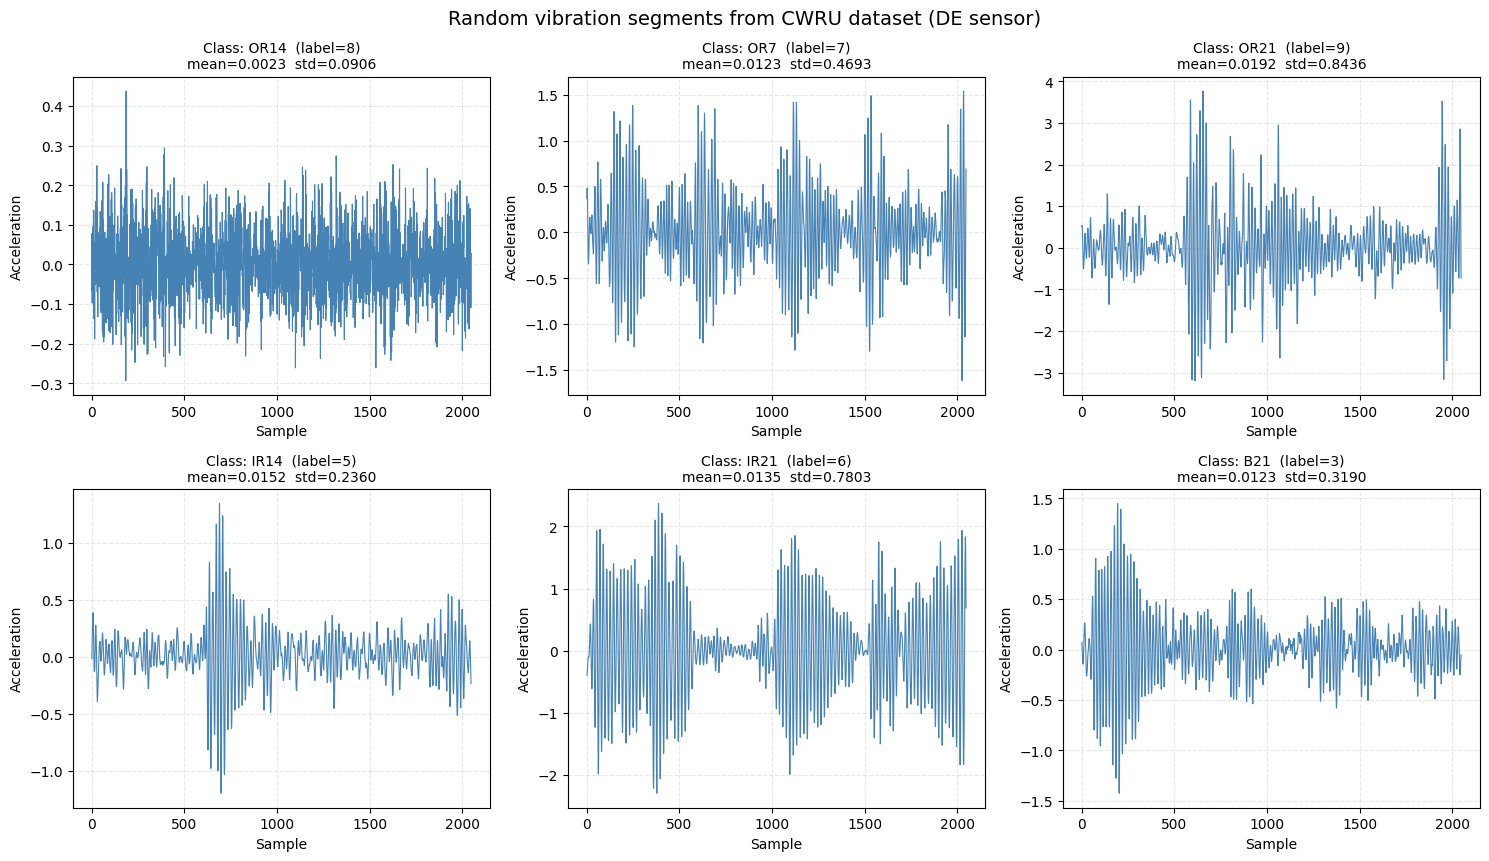


Sanity check statistics:
Min value across all loaded segments: -7.250749
Max value across all loaded segments: 7.702304
Average std per segment:          0.394256


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import random

data_dir = "../DataSets/CWRU/CWRU_Bearing_NumPy-main/Data"
test_seg_len = 2048          # longer segment → better visual waveform
max_files_to_check = 40      # limit scanning speed during test
n_plot = 6                   # how many random examples to plot

# ────────────────────────────────────────────────
def main():
    print("=== Testing load_dataset() ===")
    print(f"Data directory: {data_dir}")
    print(f"Target segment length: {test_seg_len}")

    n_plot = 6   # ← move it here

    print("\nLoading data...")
    signals, labels = load_dataset(data_dir, seg_len=test_seg_len)

    if len(signals) == 0:
        print("❌ No segments loaded. Check path / DE key / file format.")
        return

    print(f"→ Loaded {len(signals)} segments")
    print(f"→ Unique labels: {sorted(np.unique(labels))}")

    # Label distribution
    print("\nLabel distribution:")
    for lbl in sorted(np.unique(labels)):
        class_name = next((k for k, v in class_map.items() if v == lbl), f"Unknown ({lbl})")
        count = np.sum(labels == lbl)
        print(f"  Label {lbl:2d} → {class_name:8s} : {count:6d} segments")

    if len(signals) < n_plot:
        print(f"Only {len(signals)} segments available — plotting all")
        n_plot = len(signals)

    # Pick random indices (stratified-like: try to get different classes)
    unique_lbls = np.unique(labels)
    selected_idx = []

    for lbl in random.sample(list(unique_lbls), min(len(unique_lbls), n_plot)):
        candidates = np.where(labels == lbl)[0]
        if len(candidates) > 0:
            selected_idx.append(random.choice(candidates))

    # If we have fewer than n_plot, fill with random others
    while len(selected_idx) < n_plot:
        idx = random.randint(0, len(signals)-1)
        if idx not in selected_idx:
            selected_idx.append(idx)

    # ─── Plotting ────────────────────────────────────────
    fig, axes = plt.subplots(n_plot//3 + (n_plot%3>0), 3, figsize=(15, 2.8 * (n_plot//3 + 1)))
    axes = axes.flatten()

    print("\nPlotting random examples:")
    for i, idx in enumerate(selected_idx):
        sig = signals[idx]
        lbl = labels[idx]

        class_name = [k for k, v in class_map.items() if v == lbl][0] if lbl in class_map.values() else f"label {lbl}"

        axes[i].plot(sig, lw=0.8, color='steelblue')
        axes[i].set_title(f"Class: {class_name}  (label={lbl})\n"
                          f"mean={sig.mean():.4f}  std={sig.std():.4f}", fontsize=10)
        axes[i].set_xlabel("Sample")
        axes[i].set_ylabel("Acceleration")
        axes[i].grid(True, alpha=0.3, ls='--')

    for ax in axes[len(selected_idx):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.suptitle("Random vibration segments from CWRU dataset (DE sensor)", y=1.02, fontsize=14)
    plt.show()

    # Quick statistical sanity check
    print("\nSanity check statistics:")
    print(f"Min value across all loaded segments: {signals.min():.6f}")
    print(f"Max value across all loaded segments: {signals.max():.6f}")
    print(f"Average std per segment:          {np.std(signals, axis=1).mean():.6f}")

if __name__ == "__main__":
    main()